# **Notebook 1. Data Exploration & Analysis**
 This notebook explores the Weed-Crop Dataset in Precision Agriculture.
 
 **Objectives:**
 - Load and understand dataset structure
 - Analyze class distribution and imbalance
 - Visualize sample images with annotations
 - Compute bounding box statistics
 - Identify preprocessing requirements

### **1. Import Libraries**

In [21]:
# Install required packages (restart kernel after running this cell)
%pip install seaborn opencv-python pillow tqdm --user

Note: you may need to restart the kernel to use updated packages.


In [22]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict, Counter
from PIL import Image
import json
from tqdm import tqdm

# import warnings
# warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### **2. Configuration and Path Setup**

In [26]:
# Dataset configuration
DATASET_ROOT = Path("Weed-crop RGB dataset")
#DATASET_ROOT = Path("../Weed-crop RGB dataset")

# List all subdirectories (crop types)
crop_folders = [f for f in DATASET_ROOT.iterdir() if f.is_dir()]
print(f"\nFound {len(crop_folders)} crop folders:")
for folder in sorted(crop_folders):
    print(f"   -  {folder.name}")


Found 8 crop folders:
   -  Black bean
   -  Canola
   -  Corn
   -  Field pea
   -  Flax
   -  Lentil
   -  Soybean
   -  Sugar beet


### **3. Load Class Names**

In [27]:
"""
Load the classes.txt file containing all weed and crop species names.
"""

def load_classes(dataset_root):
    """Load class names from classes.txt"""
    classes_file = dataset_root / "classes.txt"
    
    if not classes_file.exists():
        # Try to find it in subdirectories
        for crop_folder in dataset_root.iterdir():
            if crop_folder.is_dir():
                alt_classes = crop_folder / "classes.txt"
                if alt_classes.exists():
                    classes_file = alt_classes
                    break
    
    if classes_file.exists():
        with open(classes_file, 'r') as f:
            classes = [line.strip() for line in f.readlines()]
        return classes
    else:
        print("⚠️ classes.txt not found. Using default class order.")
        return None

# Load classes
class_names = load_classes(DATASET_ROOT)

if class_names:
    print(f"✓ Loaded {len(class_names)} classes:")
    for idx, name in enumerate(class_names):
        print(f"   {idx}: {name}")
else:
    print("⚠️ Could not load class names. Will use numeric IDs.")

✓ Loaded 13 classes:
   0: Blackbean
   1: Canola
   2: Corn
   3: Field Pea
   4: Flax
   5: Horseweed
   6: Kochia
   7: Lentil
   8: Ragweed
   9: Redroot Pigweed
   10: Soybean
   11: Sugar beet
   12: Waterhemp


### **4. Dataset Structure Analysis**

In [28]:
"""
Scan the entire dataset to understand its structure.
"""

def scan_dataset(dataset_root):
    """
    Scan dataset and collect information about images and annotations.
    
    Returns:
        dataset_info: dict with structure information
    """
    dataset_info = {
        'crop_folders': [],
        'total_images': 0,
        'total_annotations': 0,
        'images_per_crop': {},
        'annotations_per_crop': {}
    }
    
    for crop_folder in dataset_root.iterdir():
        if not crop_folder.is_dir() or crop_folder.name.startswith('.'):
            continue
            
        crop_name = crop_folder.name
        dataset_info['crop_folders'].append(crop_name)
        
        # Look for images and labels
        img_folder = crop_folder / "images" if (crop_folder / "images").exists() else crop_folder
        lbl_folder = crop_folder / "labels" if (crop_folder / "labels").exists() else crop_folder
        
        # Count images
        img_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
        images = [f for f in img_folder.iterdir() if f.suffix in img_extensions]
        
        # Count labels
        labels = [f for f in lbl_folder.iterdir() if f.suffix == '.txt' and f.name != 'classes.txt']
        
        dataset_info['images_per_crop'][crop_name] = len(images)
        dataset_info['annotations_per_crop'][crop_name] = len(labels)
        dataset_info['total_images'] += len(images)
        dataset_info['total_annotations'] += len(labels)
    
    return dataset_info

# Scan the dataset
print("Scanning dataset structure...")
dataset_info = scan_dataset(DATASET_ROOT)

print(f"\n📊 Dataset Summary:")
print(f"   Total crop types: {len(dataset_info['crop_folders'])}")
print(f"   Total images: {dataset_info['total_images']}")
print(f"   Total annotation files: {dataset_info['total_annotations']}")

print(f"\n📈 Images per crop type:")
for crop, count in sorted(dataset_info['images_per_crop'].items()):
    print(f"   {crop:20s}: {count:4d} images")

Scanning dataset structure...

📊 Dataset Summary:
   Total crop types: 8
   Total images: 1120
   Total annotation files: 1120

📈 Images per crop type:
   Black bean          :  140 images
   Canola              :  140 images
   Corn                :  140 images
   Field pea           :  140 images
   Flax                :  140 images
   Lentil              :  140 images
   Soybean             :  140 images
   Sugar beet          :  140 images


### **5. Load All Annotations**

In [29]:
"""
Parse all YOLO format annotation files and collect statistics.
"""

def parse_yolo_annotation(label_path):
    """
    Parse a YOLO format annotation file.
    
    Format: class_id x_center y_center width height (normalized 0-1)
    
    Returns:
        List of dicts with annotation info
    """
    annotations = []
    
    try:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    
                    annotations.append({
                        'class_id': class_id,
                        'x_center': x_center,
                        'y_center': y_center,
                        'width': width,
                        'height': height,
                        'area': width * height
                    })
    except Exception as e:
        print(f"Error parsing {label_path}: {e}")
    
    return annotations

def load_all_annotations(dataset_root):
    """
    Load all annotations from the dataset.
    
    Returns:
        all_annotations: list of all annotation dicts
        class_counts: Counter object with class distribution
    """
    all_annotations = []
    class_counts = Counter()
    
    print("📝 Loading all annotations...")
    
    for crop_folder in tqdm(list(dataset_root.iterdir())):
        if not crop_folder.is_dir() or crop_folder.name.startswith('.'):
            continue
        
        lbl_folder = crop_folder / "labels" if (crop_folder / "labels").exists() else crop_folder
        
        for label_file in lbl_folder.iterdir():
            if label_file.suffix == '.txt' and label_file.name != 'classes.txt':
                annotations = parse_yolo_annotation(label_file)
                
                for ann in annotations:
                    ann['crop_type'] = crop_folder.name
                    ann['image_name'] = label_file.stem
                    all_annotations.append(ann)
                    class_counts[ann['class_id']] += 1
    
    return all_annotations, class_counts

# Load all annotations
all_annotations, class_counts = load_all_annotations(DATASET_ROOT)

print(f"\n✓ Loaded {len(all_annotations)} total object instances")
print(f"✓ Found {len(class_counts)} unique classes")

📝 Loading all annotations...


100%|██████████| 8/8 [00:15<00:00,  1.98s/it]


✓ Loaded 17693 total object instances
✓ Found 13 unique classes


### **6. Class Distribution Analysis**

In [31]:
"""
Analyze and visualize class distribution to identify imbalance.
"""

# Create a DataFrame for easier analysis
df_annotations = pd.DataFrame(all_annotations)

print("\n📊 Class Distribution:")
print("="*60)

# Check if we have annotations
if len(all_annotations) == 0:
    print("⚠️ No annotations found! Please check:")
    print("   1. Dataset path is correct")
    print("   2. Label files exist in 'labels' subdirectories")
    print("   3. Label files are in YOLO format (.txt)")
else:
    class_distribution = []
    for class_id, count in sorted(class_counts.items()):
        class_name = class_names[class_id] if class_names and class_id < len(class_names) else f"Class_{class_id}"
        percentage = (count / len(all_annotations)) * 100
        class_distribution.append({
            'Class ID': class_id,
            'Class Name': class_name,
            'Count': count,
            'Percentage': percentage
        })
        print(f"{class_id:2d} | {class_name:25s} | {count:6d} instances ({percentage:5.2f}%)")

    df_class_dist = pd.DataFrame(class_distribution)

    # Calculate imbalance ratio
    max_count = df_class_dist['Count'].max()
    min_count = df_class_dist['Count'].min()
    imbalance_ratio = max_count / min_count

    print(f"\n⚖️ Imbalance Ratio: {imbalance_ratio:.2f}:1 (max/min)")
    print(f"   Most common class: {df_class_dist.loc[df_class_dist['Count'].idxmax(), 'Class Name']} ({max_count} instances)")
    print(f"   Least common class: {df_class_dist.loc[df_class_dist['Count'].idxmin(), 'Class Name']} ({min_count} instances)")



📊 Class Distribution:
 0 | Blackbean                 |   1970 instances (11.13%)
 1 | Canola                    |   1804 instances (10.20%)
 2 | Corn                      |   1476 instances ( 8.34%)
 3 | Field Pea                 |   1384 instances ( 7.82%)
 4 | Flax                      |   1745 instances ( 9.86%)
 5 | Horseweed                 |    407 instances ( 2.30%)
 6 | Kochia                    |    851 instances ( 4.81%)
 7 | Lentil                    |   1706 instances ( 9.64%)
 8 | Ragweed                   |   1086 instances ( 6.14%)
 9 | Redroot Pigweed           |    635 instances ( 3.59%)
10 | Soybean                   |   2877 instances (16.26%)
11 | Sugar beet                |   1057 instances ( 5.97%)
12 | Waterhemp                 |    695 instances ( 3.93%)

⚖️ Imbalance Ratio: 7.07:1 (max/min)
   Most common class: Soybean (2877 instances)
   Least common class: Horseweed (407 instances)


### **7. Visualize Class Distribution**

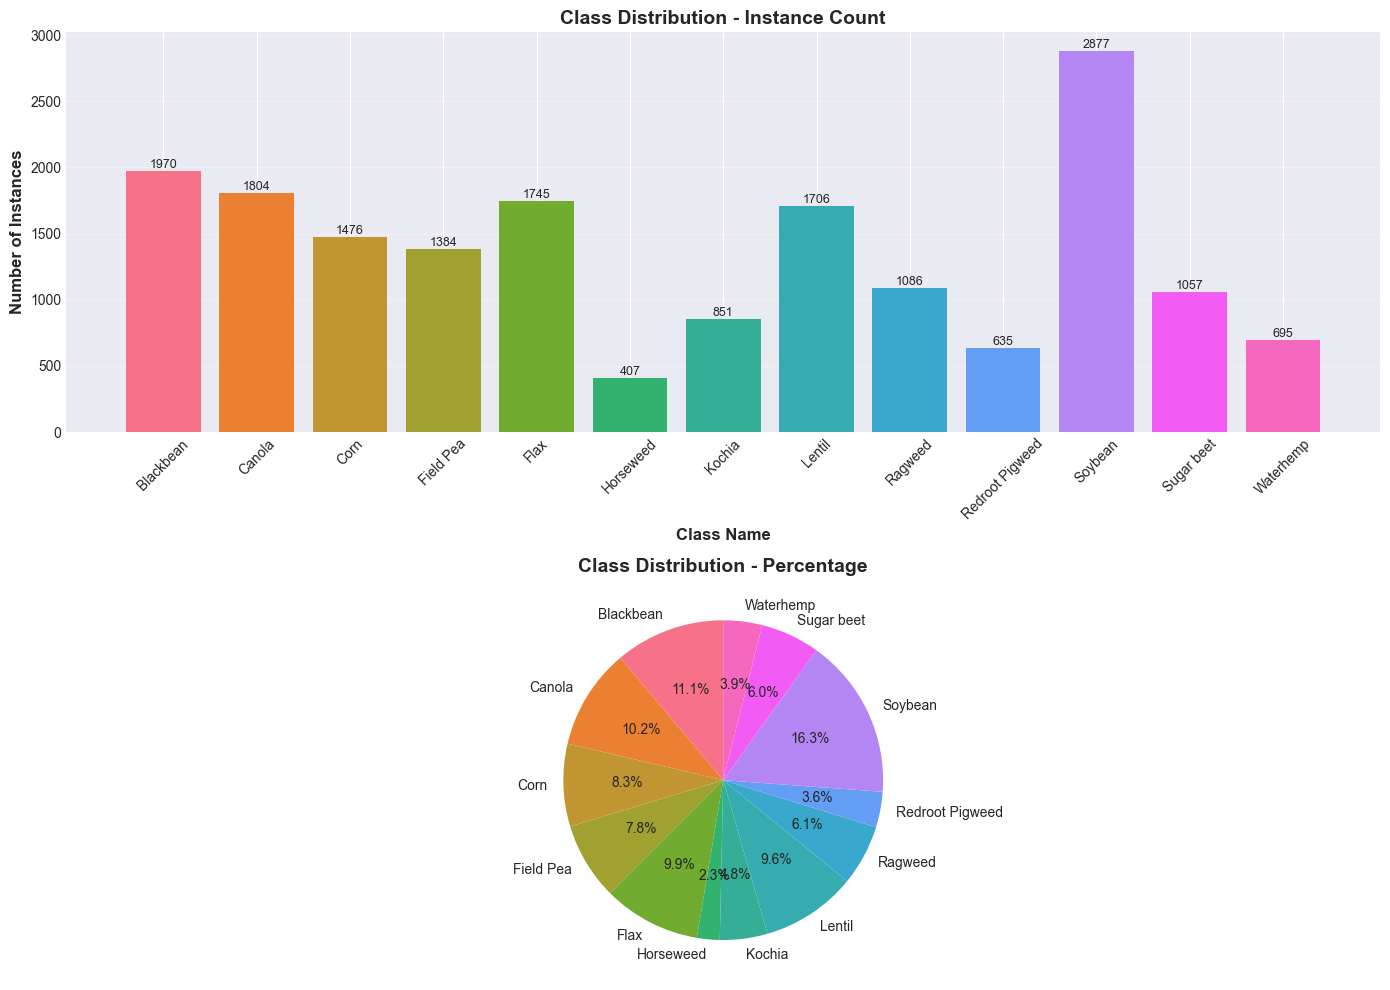

✓ Saved class distribution plot as 'class_distribution.png'


In [32]:
"""
Create visualizations of class distribution.
"""

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Bar plot
ax1 = axes[0]
colors = sns.color_palette("husl", len(df_class_dist))
bars = ax1.bar(df_class_dist['Class Name'], df_class_dist['Count'], color=colors)
ax1.set_xlabel('Class Name', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Instances', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution - Instance Count', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

# Pie chart
ax2 = axes[1]
ax2.pie(df_class_dist['Count'], labels=df_class_dist['Class Name'], 
        autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved class distribution plot as 'class_distribution.png'")

### **8. Bounding Box Size Analysis**

In [33]:
"""
Analyze bounding box sizes to understand object scales.
"""

# Calculate absolute sizes (assuming average image size)
# We'll compute actual sizes when we load images

df_annotations['area_normalized'] = df_annotations['width'] * df_annotations['height']
df_annotations['aspect_ratio'] = df_annotations['width'] / df_annotations['height']

print("\n📏 Bounding Box Statistics (Normalized Coordinates):")
print("="*60)

stats = df_annotations[['width', 'height', 'area_normalized']].describe()
print(stats)

# Categorize by size (COCO definition adapted)
# Small: area < 0.01 (1% of image)
# Medium: 0.01 <= area < 0.04
# Large: area >= 0.04

df_annotations['size_category'] = pd.cut(
    df_annotations['area_normalized'],
    bins=[0, 0.01, 0.04, 1.0],
    labels=['Small', 'Medium', 'Large']
)

size_distribution = df_annotations['size_category'].value_counts()
print(f"\n📊 Object Size Distribution:")
for size, count in size_distribution.items():
    percentage = (count / len(df_annotations)) * 100
    print(f"   {size:10s}: {count:6d} objects ({percentage:5.2f}%)")


📏 Bounding Box Statistics (Normalized Coordinates):
              width        height  area_normalized
count  17693.000000  17693.000000     17693.000000
mean       0.115305      0.139341         0.020401
std        0.080986      0.080447         0.025216
min        0.010000      0.020000         0.000200
25%        0.060000      0.080000         0.004800
50%        0.090000      0.130000         0.011700
75%        0.150000      0.180000         0.026000
max        0.790000      0.810000         0.413100

📊 Object Size Distribution:
   Small     :   7999 objects (45.21%)
   Medium    :   7145 objects (40.38%)
   Large     :   2549 objects (14.41%)


### **9. Visualize Bounding Box Statistics**

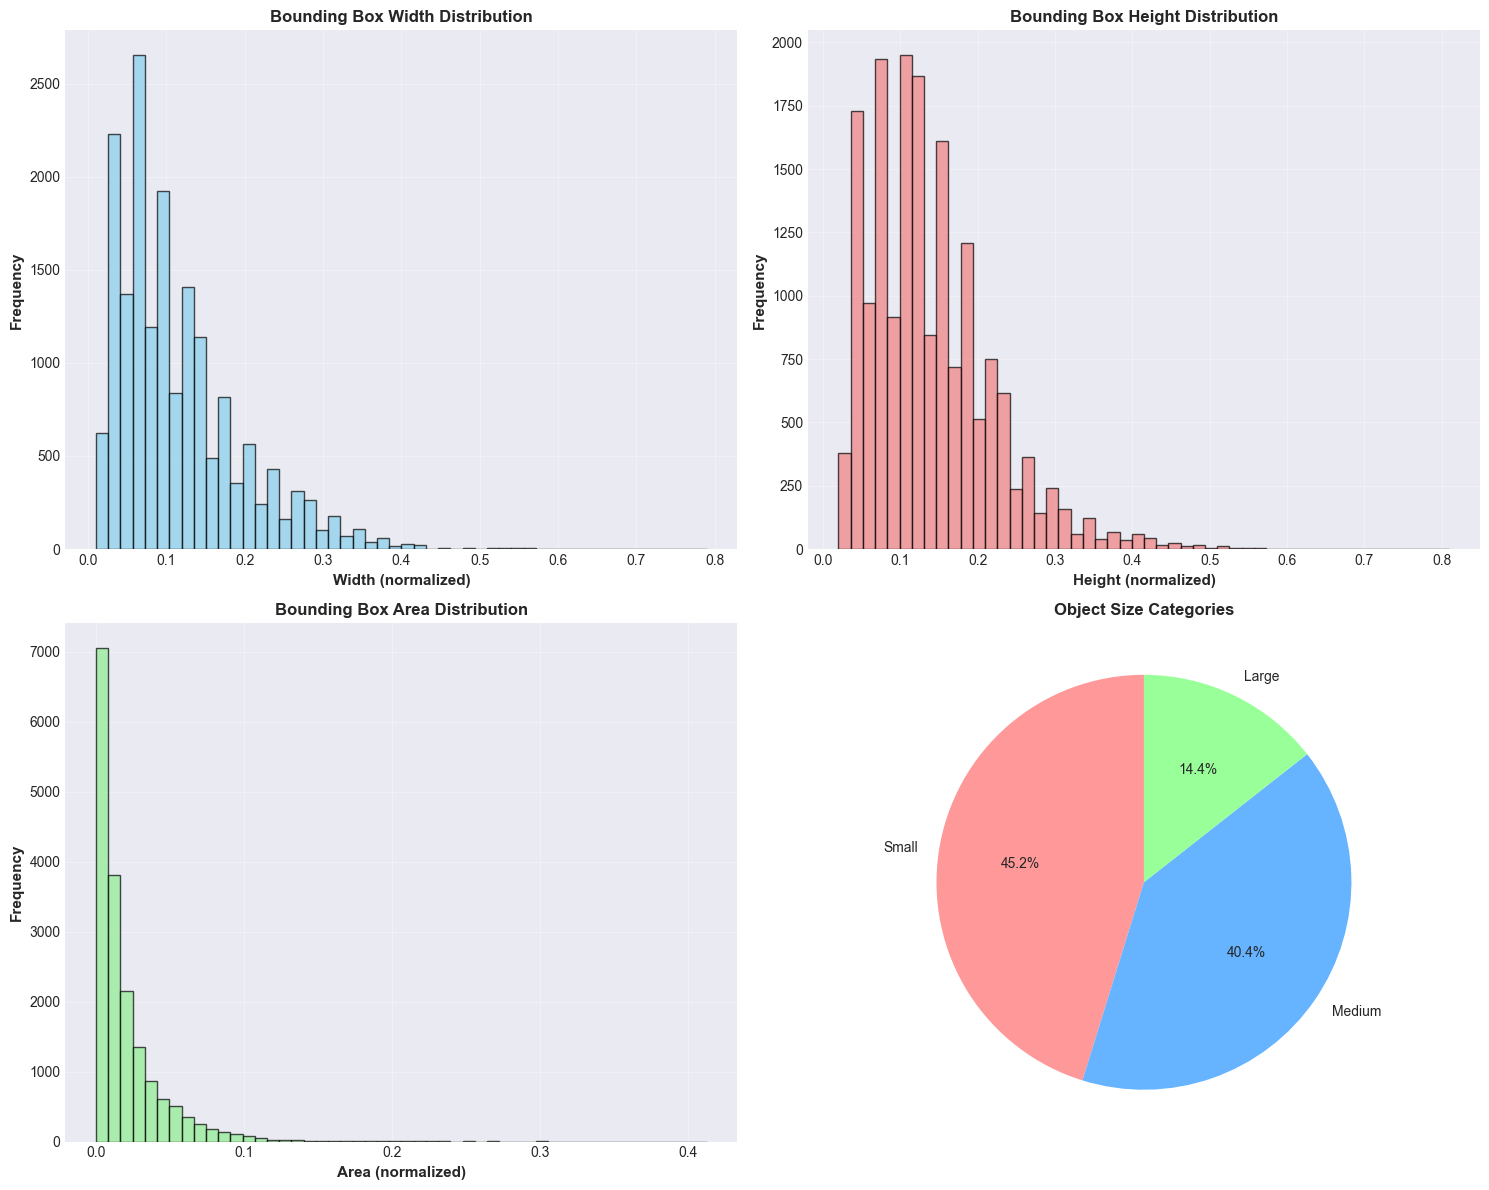

✓ Saved bounding box statistics plot as 'bbox_statistics.png'


In [34]:
"""
Create visualizations for bounding box analysis.
"""

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Width distribution
ax1 = axes[0, 0]
ax1.hist(df_annotations['width'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Width (normalized)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Bounding Box Width Distribution', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

# Height distribution
ax2 = axes[0, 1]
ax2.hist(df_annotations['height'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Height (normalized)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Bounding Box Height Distribution', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

# Area distribution
ax3 = axes[1, 0]
ax3.hist(df_annotations['area_normalized'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Area (normalized)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Bounding Box Area Distribution', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)

# Size category pie chart
ax4 = axes[1, 1]
colors_pie = ['#ff9999', '#66b3ff', '#99ff99']
ax4.pie(size_distribution, labels=size_distribution.index, autopct='%1.1f%%', 
        startangle=90, colors=colors_pie)
ax4.set_title('Object Size Categories', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('bbox_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved bounding box statistics plot as 'bbox_statistics.png'")

### **10. Per-Class Size Analysis**

In [35]:
"""
Analyze bounding box sizes per class to identify small weed instances.
"""

print("\n📊 Per-Class Bounding Box Statistics:")
print("="*80)

class_size_stats = []

for class_id in sorted(df_annotations['class_id'].unique()):
    class_data = df_annotations[df_annotations['class_id'] == class_id]
    class_name = class_names[class_id] if class_names and class_id < len(class_names) else f"Class_{class_id}"
    
    mean_area = class_data['area_normalized'].mean()
    median_area = class_data['area_normalized'].median()
    mean_width = class_data['width'].mean()
    mean_height = class_data['height'].mean()
    
    # Count small objects
    small_count = len(class_data[class_data['size_category'] == 'Small'])
    small_percentage = (small_count / len(class_data)) * 100
    
    class_size_stats.append({
        'Class Name': class_name,
        'Count': len(class_data),
        'Mean Area': mean_area,
        'Median Area': median_area,
        'Mean Width': mean_width,
        'Mean Height': mean_height,
        'Small Objects': small_count,
        'Small %': small_percentage
    })
    
    print(f"{class_name:25s} | Instances: {len(class_data):5d} | "
          f"Avg Area: {mean_area:.4f} | Small: {small_percentage:5.1f}%")

df_class_size = pd.DataFrame(class_size_stats)


📊 Per-Class Bounding Box Statistics:
Blackbean                 | Instances:  1970 | Avg Area: 0.0186 | Small:  42.8%
Canola                    | Instances:  1804 | Avg Area: 0.0267 | Small:  37.3%
Corn                      | Instances:  1476 | Avg Area: 0.0462 | Small:  20.3%
Field Pea                 | Instances:  1384 | Avg Area: 0.0287 | Small:  22.6%
Flax                      | Instances:  1745 | Avg Area: 0.0220 | Small:  45.0%
Horseweed                 | Instances:   407 | Avg Area: 0.0071 | Small:  76.9%
Kochia                    | Instances:   851 | Avg Area: 0.0106 | Small:  57.1%
Lentil                    | Instances:  1706 | Avg Area: 0.0126 | Small:  58.6%
Ragweed                   | Instances:  1086 | Avg Area: 0.0106 | Small:  58.7%
Redroot Pigweed           | Instances:   635 | Avg Area: 0.0120 | Small:  45.5%
Soybean                   | Instances:  2877 | Avg Area: 0.0155 | Small:  59.2%
Sugar beet                | Instances:  1057 | Avg Area: 0.0219 | Small:  32.4%
Wa

### **11. Utility Functions for Visualization**

In [ ]:
def find_image_path(dataset_root, image_name, crop_type):
    """Find the full path to an image file."""
    crop_folder = dataset_root / crop_type
    
    # Check in images subdirectory first
    img_folder = crop_folder / "images" if (crop_folder / "images").exists() else crop_folder
    
    # Try different extensions
    extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    for ext in extensions:
        img_path = img_folder / f"{image_name}{ext}"
        if img_path.exists():
            return img_path
    
    return None

def draw_yolo_boxes(image, annotations, class_names):
    """Draw YOLO format bounding boxes on image."""
    img_height, img_width = image.shape[:2]
    img_copy = image.copy()
    
    # Generate colors for each class
    np.random.seed(42)
    colors = {}
    
    for ann in annotations:
        class_id = ann['class_id']
        
        # Get or generate color for this class
        if class_id not in colors:
            colors[class_id] = tuple(np.random.randint(0, 255, 3).tolist())
        
        color = colors[class_id]
        
        # Convert YOLO format (normalized) to pixel coordinates
        x_center = ann['x_center'] * img_width
        y_center = ann['y_center'] * img_height
        width = ann['width'] * img_width
        height = ann['height'] * img_height
        
        # Calculate corner points
        x1 = int(x_center - width / 2)
        y1 = int(y_center - height / 2)
        x2 = int(x_center + width / 2)
        y2 = int(y_center + height / 2)
        
        # Draw rectangle
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
        
        # Add label
        class_name = class_names[class_id] if class_names and class_id < len(class_names) else f"Class_{class_id}"
        label = f"{class_name}"
        
        # Draw label background
        (label_width, label_height), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img_copy, (x1, y1 - label_height - 5), (x1 + label_width, y1), color, -1)
        
        # Draw label text
        cv2.putText(img_copy, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    return img_copy

def visualize_sample_images(dataset_root, all_annotations, class_names, n_samples=6):
    """Visualize random sample images with annotations."""
    import random
    
    # Group annotations by image
    image_annotations = defaultdict(list)
    for ann in all_annotations:
        key = (ann['crop_type'], ann['image_name'])
        image_annotations[key].append(ann)
    
    # Sample random images using random.sample (simpler)
    all_keys = list(image_annotations.keys())
    sample_keys = random.sample(all_keys, min(n_samples, len(all_keys)))
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, key in enumerate(sample_keys):
        crop_type, image_name = key
        annotations = image_annotations[key]
        
        # Find and load image
        img_path = find_image_path(dataset_root, image_name, crop_type)
        
        if img_path is None:
            print(f"⚠️ Image not found: {image_name}")
            continue
        
        # Load image
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Draw boxes
        image_with_boxes = draw_yolo_boxes(image, annotations, class_names)
        
        # Display
        axes[idx].imshow(image_with_boxes)
        axes[idx].set_title(f"{crop_type} - {len(annotations)} objects", fontsize=11, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(sample_keys), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved sample images as 'sample_images.png'")

### **12. Visualize Sample Images**


🖼️ Visualizing sample images with annotations...


NameError: name 'find_image_path' is not defined

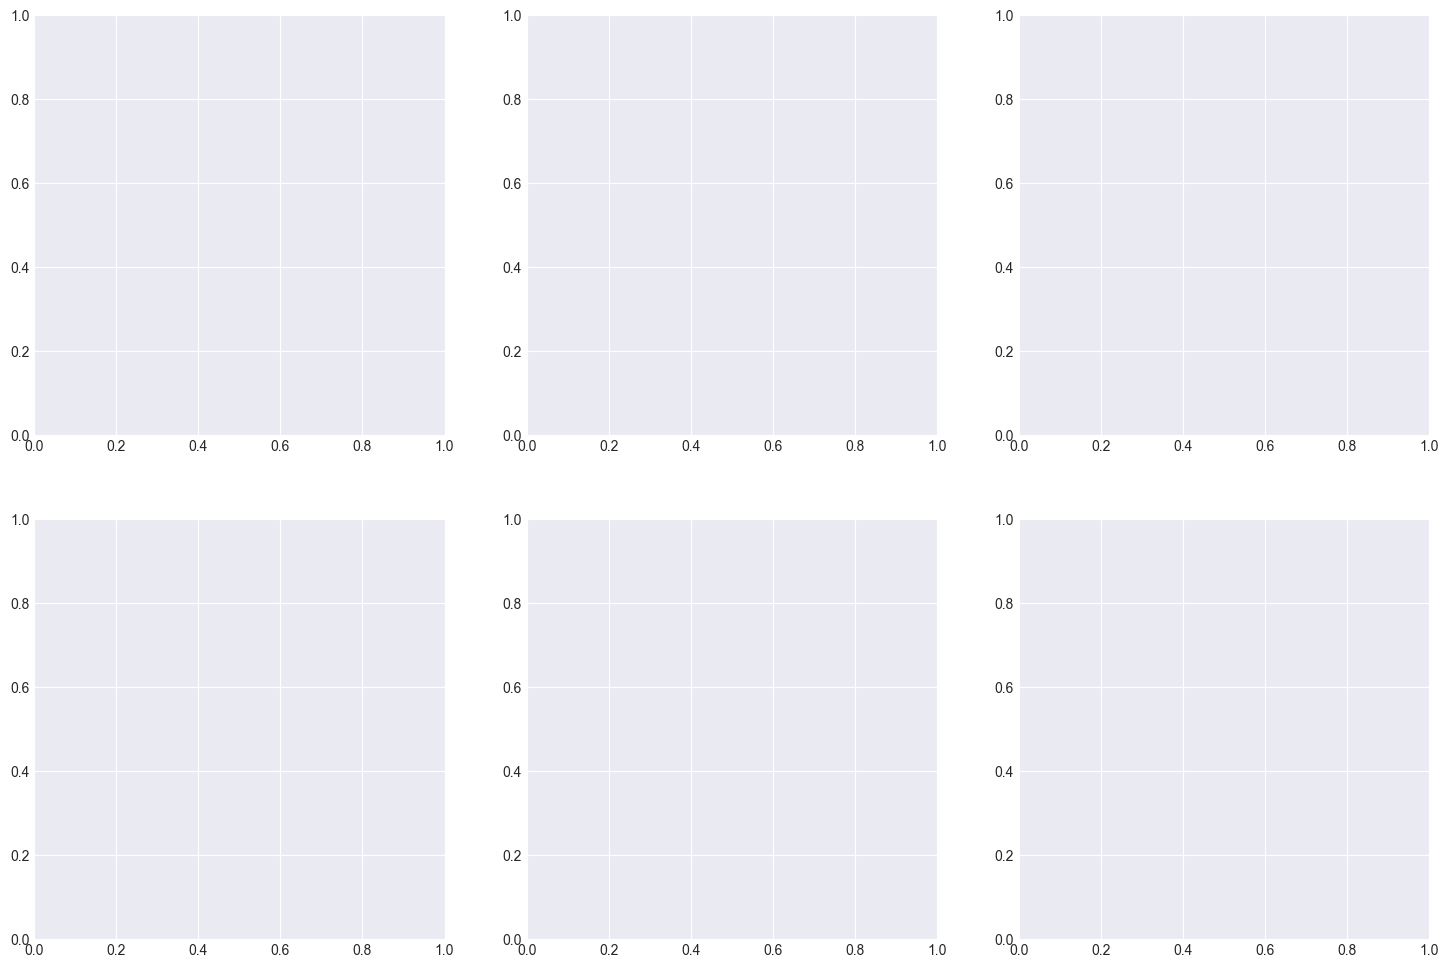

In [ ]:
"""
Display sample images with bounding box annotations.
"""

print("\n Visualizing sample images with annotations...")
visualize_sample_images(DATASET_ROOT, all_annotations, class_names, n_samples=6)

### **13. Identify Challenging Cases**

In [ ]:
"""
Find images with multiple classes and high object density.
"""

# Group by image
image_stats = defaultdict(lambda: {'count': 0, 'classes': set(), 'crop_type': None})

for ann in all_annotations:
    key = (ann['crop_type'], ann['image_name'])
    image_stats[key]['count'] += 1
    image_stats[key]['classes'].add(ann['class_id'])
    image_stats[key]['crop_type'] = ann['crop_type']

# Convert to list
image_stats_list = []
for (crop_type, img_name), stats in image_stats.items():
    image_stats_list.append({
        'crop_type': crop_type,
        'image_name': img_name,
        'object_count': stats['count'],
        'class_count': len(stats['classes'])
    })

df_image_stats = pd.DataFrame(image_stats_list)

print("\n🔍 Image-level Statistics:")
print(f"   Average objects per image: {df_image_stats['object_count'].mean():.2f}")
print(f"   Max objects in single image: {df_image_stats['object_count'].max()}")
print(f"   Images with multiple classes: {len(df_image_stats[df_image_stats['class_count'] > 1])}")

# Find most challenging images (high object count, multiple classes)
df_image_stats['challenge_score'] = df_image_stats['object_count'] * df_image_stats['class_count']
top_challenging = df_image_stats.nlargest(10, 'challenge_score')

print(f"\n🎯 Top 10 Most Challenging Images (by object count × class diversity):")
print(top_challenging[['crop_type', 'image_name', 'object_count', 'class_count', 'challenge_score']])


🔍 Image-level Statistics:
   Average objects per image: 15.80
   Max objects in single image: 59
   Images with multiple classes: 1090

🎯 Top 10 Most Challenging Images (by object count × class diversity):
       crop_type                    image_name  object_count  class_count  \
961      Soybean  field_cas22_1657833271039_11            52            4   
1105  Sugar beet  field_cas22_1657835629317_15            41            5   
969      Soybean  field_cas22_1657833612244_10            51            4   
970      Soybean  field_cas22_1657833613330_17            50            4   
690         Flax  field_cas22_1657835261183_10            28            7   
127   Black bean  field_cas22_1657835249758_33            36            5   
973      Soybean  field_cas22_1657833615450_30            45            4   
971      Soybean  field_cas22_1657833614246_22            59            3   
137   Black bean  field_cas22_1657835684072_26            29            6   
953      Soybean  field

### **14. Summary and Key Findings**

In [ ]:
"""
Summarize key findings from data exploration.
"""

print("\n" + "="*80)
print("📋 DATA EXPLORATION SUMMARY")
print("="*80)

print(f"\n1️⃣ DATASET OVERVIEW:")
print(f"   • Total images: {dataset_info['total_images']}")
print(f"   • Total object instances: {len(all_annotations)}")
print(f"   • Number of classes: {len(class_counts)}")
print(f"   • Crop types: {len(dataset_info['crop_folders'])}")

print(f"\n2️⃣ CLASS IMBALANCE:")
print(f"   • Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"   • Most common: {df_class_dist.loc[df_class_dist['Count'].idxmax(), 'Class Name']} ({max_count} instances)")
print(f"   • Least common: {df_class_dist.loc[df_class_dist['Count'].idxmin(), 'Class Name']} ({min_count} instances)")

print(f"\n3️⃣ OBJECT SIZE DISTRIBUTION:")
for size, count in size_distribution.items():
    percentage = (count / len(df_annotations)) * 100
    print(f"   • {size}: {percentage:.1f}% of objects")

print(f"\n4️⃣ KEY CHALLENGES IDENTIFIED:")
print(f"   • Severe class imbalance requires targeted preprocessing")
print(f"   • High proportion of small objects ({size_distribution.get('Small', 0) / len(df_annotations) * 100:.1f}%)")
print(f"   • Variable object density per image (avg: {df_image_stats['object_count'].mean():.1f})")

print(f"\n5️⃣ NEXT STEPS:")
print(f"   ✓ Implement selective majority class undersampling")
print(f"   ✓ Apply CLAHE for illumination normalization")
print(f"   ✓ Use context-aware cropping to reduce easy crop instances")
print(f"   ✓ Focus on improving small object detection (AP_S metric)")

print("\n" + "="*80)
print("✅ Data exploration complete! Ready for preprocessing.")
print("="*80)

# %% Cell 16: Save Exploration Results
"""
Save exploration results for later use.
"""

# Save DataFrames
df_annotations.to_csv('annotations_analysis.csv', index=False)
df_class_dist.to_csv('class_distribution.csv', index=False)
df_image_stats.to_csv('image_statistics.csv', index=False)

# Save summary statistics as JSON
summary_stats = {
    'total_images': int(dataset_info['total_images']),
    'total_annotations': len(all_annotations),
    'num_classes': len(class_counts),
    'imbalance_ratio': float(imbalance_ratio),
    'size_distribution': {
        'small': int(size_distribution.get('Small', 0)),
        'medium': int(size_distribution.get('Medium', 0)),
        'large': int(size_distribution.get('Large', 0))
    },
    'avg_objects_per_image': float(df_image_stats['object_count'].mean()),
    'class_names': class_names
}

with open('dataset_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("\n💾 Saved exploration results:")
print("   • annotations_analysis.csv")
print("   • class_distribution.csv")
print("   • image_statistics.csv")
print("   • dataset_summary.json")
print("   • Visualization plots (PNG files)")


📋 DATA EXPLORATION SUMMARY

1️⃣ DATASET OVERVIEW:
   • Total images: 1120
   • Total object instances: 17693
   • Number of classes: 13
   • Crop types: 8

2️⃣ CLASS IMBALANCE:
   • Imbalance ratio: 7.07:1
   • Most common: Soybean (2877 instances)
   • Least common: Horseweed (407 instances)

3️⃣ OBJECT SIZE DISTRIBUTION:
   • Small: 45.2% of objects
   • Medium: 40.4% of objects
   • Large: 14.4% of objects

4️⃣ KEY CHALLENGES IDENTIFIED:
   • Severe class imbalance requires targeted preprocessing
   • High proportion of small objects (45.2%)
   • Variable object density per image (avg: 15.8)

5️⃣ NEXT STEPS:
   ✓ Implement selective majority class undersampling
   ✓ Apply CLAHE for illumination normalization
   ✓ Use context-aware cropping to reduce easy crop instances
   ✓ Focus on improving small object detection (AP_S metric)

✅ Data exploration complete! Ready for preprocessing.

💾 Saved exploration results:
   • annotations_analysis.csv
   • class_distribution.csv
   • image_s